# **Project Name - Tourism Experience Analytics: Classification, Prediction, and Recommendation System**


# **Project Summary -**

This project developed an integrated data intelligence platform for the tourism industry, focusing on three core objectives: Analytics, Prediction, and Personalization. By processing a large-scale dataset of traveler interactions, the system provides a 360-degree view of tourism trends.

- Tourism Analytics: Built an interactive dashboard to visualize popular attractions and visitor demographics, enabling data-driven decision-making for travel agencies.

- Behavioral Classification: Developed a machine learning model to classify travelers into segments (e.g., Solo, Family, Couples) based on their profiles and attraction preferences, allowing for targeted marketing.

- Recommendation Engine: Implemented a collaborative filtering system that suggests personalized attractions to users by identifying similar traveler patterns, significantly enhancing user engagement.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Travel agencies and online booking platforms use data analytics to improve customer experiences through tailored suggestions, satisfaction forecasting, and behavior categorization. The project analyzes user tastes, trip habits, and site attributes to meet three key goals: regression, classification, and recommendation.

**Business Use Cases:**

- **Personalized Recommendations:** Suggest attractions based on users' past visits, preferences, and demographic data, improving user experience.
- **Tourism Analytics:** Provide insights into popular attractions and regions, enabling tourism businesses to adjust their offerings accordingly.
- **Customer Segmentation:** Classify users into segments based on their travel behavior, allowing for targeted promotions.
- **Increasing Customer Retention:** By offering personalized recommendations, businesses can boost customer loyalty and retention.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [ ]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path="/content/drive/MyDrive/datasets/Tourism Dataset/cleaned_data"

In [ ]:
# Loading all cleaned datasets

df_txn = pd.read_csv(f"{data_path}/transactions_clean.csv")
df_user = pd.read_csv(f"{data_path}/user_clean.csv")
df_city = pd.read_csv(f"{data_path}/city_clean.csv")
df_country = pd.read_csv(f"{data_path}/country_clean.csv")
df_continent = pd.read_csv(f"{data_path}/continent_clean.csv")
df_region = pd.read_csv(f"{data_path}/region_clean.csv")
df_item = pd.read_csv(f"{data_path}/item_clean.csv")
df_type = pd.read_csv(f"{data_path}/type_clean.csv")
df_visit = pd.read_csv(f"{data_path}/mode_clean.csv")

### Dataset Merging

#### Creating master dataset

In [ ]:
# Start with Transactions
df_master = df_txn.copy()

In [ ]:
print(df_master.shape)
print(df_master.isnull().sum())

(52930, 7)
TransactionId    0
UserId           0
VisitYear        0
VisitMonth       0
VisitMode        0
AttractionId     0
Rating           0
dtype: int64


In [ ]:
# Merge User Data
df_master = df_master.merge(df_user, on="UserId", how="left")

In [ ]:
print(df_master.shape)
print(df_master.isnull().sum())

(52930, 11)
TransactionId    0
UserId           0
VisitYear        0
VisitMonth       0
VisitMode        0
AttractionId     0
Rating           0
ContinentId      8
RegionId         8
CountryId        8
CityId           8
dtype: int64


- If rows increase → duplicate issue
- If many nulls → wrong key

In [ ]:
df_master = df_master.dropna(subset=[
    "CityId",
    "CountryId",
    "RegionId",
    "ContinentId"
])

“Only 0.015% of rows had missing demographic data after merging. Since this was negligible and imputing geographic IDs could introduce bias, I removed those rows to maintain data integrity.”

In [ ]:
# Merge Item (Attraction) Data
df_master = df_master.merge(df_item, on="AttractionId", how="left")

In [ ]:
print(df_master.shape)
print(df_master.isnull().sum())

(52922, 15)
TransactionId        0
UserId               0
VisitYear            0
VisitMonth           0
VisitMode            0
AttractionId         0
Rating               0
ContinentId          0
RegionId             0
CountryId            0
CityId               0
AttractionCityId     0
AttractionTypeId     0
Attraction           0
AttractionAddress    0
dtype: int64


In [ ]:
# Merge Attraction City
df_master = df_master.merge(
    df_city,
    left_on="AttractionCityId",
    right_on="CityId",
    how="left"
)

In [ ]:
df_master.rename(columns={
    "CityName": "AttractionCityName"
}, inplace=True)

In [ ]:
print(df_master.shape)
print(df_master.isnull().sum())

(52922, 18)
TransactionId         0
UserId                0
VisitYear             0
VisitMonth            0
VisitMode             0
AttractionId          0
Rating                0
ContinentId           0
RegionId              0
CountryId_x           0
CityId_x              0
AttractionCityId      0
AttractionTypeId      0
Attraction            0
AttractionAddress     0
CityId_y              0
AttractionCityName    0
CountryId_y           0
dtype: int64


In [ ]:
df_master.rename(columns={
    "CountryId_x": "UserCountryId",
    "CityId_x": "UserCityId",
    "CountryId_y": "AttractionCountryId",
    "CityId_y": "AttractionCityId_fromCityTable"
}, inplace=True)

In [ ]:
(df_master["AttractionCityId"] == df_master["AttractionCityId_fromCityTable"]).all()
df_master.drop(columns=["AttractionCityId_fromCityTable"], inplace=True)

In [ ]:
# Merge Attraction Country
df_master = df_master.merge(
    df_country,
    left_on="AttractionCountryId",
    right_on="CountryId",
    how="left"
)

In [ ]:
df_master.rename(columns={"Country": "AttractionCountry"}, inplace=True)

In [ ]:
print(df_master.shape)
print(df_master.isnull().sum())

(52922, 20)
TransactionId          0
UserId                 0
VisitYear              0
VisitMonth             0
VisitMode              0
AttractionId           0
Rating                 0
ContinentId            0
RegionId_x             0
UserCountryId          0
UserCityId             0
AttractionCityId       0
AttractionTypeId       0
Attraction             0
AttractionAddress      0
AttractionCityName     0
AttractionCountryId    0
CountryId              0
AttractionCountry      0
RegionId_y             0
dtype: int64


In [ ]:
df_master.rename(columns={
    "RegionId_x": "UserRegionId",
    "RegionId_y": "AttractionRegionId"
}, inplace=True)


In [ ]:
# Merge Region
df_master = df_master.merge(
    df_region.add_prefix("User_"),
    left_on="UserRegionId",
    right_on="User_RegionId",
    how="left"
)
df_master = df_master.merge(
    df_region.add_prefix("Attraction_"),
    left_on="AttractionRegionId",
    right_on="Attraction_RegionId",
    how="left"
)


In [ ]:
print(df_master.shape)
print(df_master.isnull().sum())

(52922, 26)
TransactionId             0
UserId                    0
VisitYear                 0
VisitMonth                0
VisitMode                 0
AttractionId              0
Rating                    0
ContinentId               0
UserRegionId              0
UserCountryId             0
UserCityId                0
AttractionCityId          0
AttractionTypeId          0
Attraction                0
AttractionAddress         0
AttractionCityName        0
AttractionCountryId       0
CountryId                 0
AttractionCountry         0
AttractionRegionId        0
User_Region               0
User_RegionId             0
User_ContinentId          0
Attraction_Region         0
Attraction_RegionId       0
Attraction_ContinentId    0
dtype: int64


In [ ]:
# Merge Continent
df_master = df_master.merge(df_continent, on="ContinentId", how="left")

In [ ]:
print(df_master.shape)
print(df_master.isnull().sum())

(52922, 27)
TransactionId             0
UserId                    0
VisitYear                 0
VisitMonth                0
VisitMode                 0
AttractionId              0
Rating                    0
ContinentId               0
UserRegionId              0
UserCountryId             0
UserCityId                0
AttractionCityId          0
AttractionTypeId          0
Attraction                0
AttractionAddress         0
AttractionCityName        0
AttractionCountryId       0
CountryId                 0
AttractionCountry         0
AttractionRegionId        0
User_Region               0
User_RegionId             0
User_ContinentId          0
Attraction_Region         0
Attraction_RegionId       0
Attraction_ContinentId    0
Continent                 0
dtype: int64


In [ ]:
# Merge Attraction Type
df_master = df_master.merge(df_type, on="AttractionTypeId", how="left")

In [ ]:
print(df_master.shape)
print(df_master.isnull().sum())

(52922, 28)
TransactionId             0
UserId                    0
VisitYear                 0
VisitMonth                0
VisitMode                 0
AttractionId              0
Rating                    0
ContinentId               0
UserRegionId              0
UserCountryId             0
UserCityId                0
AttractionCityId          0
AttractionTypeId          0
Attraction                0
AttractionAddress         0
AttractionCityName        0
AttractionCountryId       0
CountryId                 0
AttractionCountry         0
AttractionRegionId        0
User_Region               0
User_RegionId             0
User_ContinentId          0
Attraction_Region         0
Attraction_RegionId       0
Attraction_ContinentId    0
Continent                 0
AttractionType            0
dtype: int64


In [ ]:
# Merge Visit Mode Table
df_master = df_master.merge(
    df_visit,
    left_on="VisitMode",
    right_on="VisitModeId",
    how="left"
)

In [ ]:
print(df_master.shape)
print(df_master.isnull().sum())

(52922, 30)
TransactionId             0
UserId                    0
VisitYear                 0
VisitMonth                0
VisitMode_x               0
AttractionId              0
Rating                    0
ContinentId               0
UserRegionId              0
UserCountryId             0
UserCityId                0
AttractionCityId          0
AttractionTypeId          0
Attraction                0
AttractionAddress         0
AttractionCityName        0
AttractionCountryId       0
CountryId                 0
AttractionCountry         0
AttractionRegionId        0
User_Region               0
User_RegionId             0
User_ContinentId          0
Attraction_Region         0
Attraction_RegionId       0
Attraction_ContinentId    0
Continent                 0
AttractionType            0
VisitModeId               0
VisitMode_y               0
dtype: int64


In [ ]:
df_master = df_master.drop(columns=["VisitMode_x"])
df_master = df_master.rename(columns={"VisitMode_y": "VisitMode"})

In [ ]:
print(df_master.shape)
print(df_master.isnull().sum())

(52922, 29)
TransactionId             0
UserId                    0
VisitYear                 0
VisitMonth                0
AttractionId              0
Rating                    0
ContinentId               0
UserRegionId              0
UserCountryId             0
UserCityId                0
AttractionCityId          0
AttractionTypeId          0
Attraction                0
AttractionAddress         0
AttractionCityName        0
AttractionCountryId       0
CountryId                 0
AttractionCountry         0
AttractionRegionId        0
User_Region               0
User_RegionId             0
User_ContinentId          0
Attraction_Region         0
Attraction_RegionId       0
Attraction_ContinentId    0
Continent                 0
AttractionType            0
VisitModeId               0
VisitMode                 0
dtype: int64


### Dataset First View

In [ ]:
# Dataset First Look
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df_master.head()

,TransactionId,UserId,VisitYear,VisitMonth,AttractionId,Rating,ContinentId,UserRegionId,UserCountryId,UserCityId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionCityName,AttractionCountryId,CountryId,AttractionCountry,AttractionRegionId,User_Region,User_RegionId,User_ContinentId,Attraction_Region,Attraction_RegionId,Attraction_ContinentId,Continent,AttractionType,VisitModeId,VisitMode
0,3,70456,2022,10,640,5,5.0,21.0,163.0,4341.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Douala,1,1,Cameroon,1,Western Europe,21,5,Central Africa,1,1,Europe,Nature & Wildlife Areas,2,Couples
1,8,7567,2022,10,640,5,2.0,8.0,48.0,464.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Douala,1,1,Cameroon,1,Northern America,8,2,Central Africa,1,1,America,Nature & Wildlife Areas,4,Friends
2,9,79069,2022,10,640,5,2.0,9.0,54.0,774.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Douala,1,1,Cameroon,1,South America,9,2,Central Africa,1,1,America,Nature & Wildlife Areas,3,Family
3,10,31019,2022,10,640,3,5.0,17.0,135.0,583.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Douala,1,1,Cameroon,1,Central Europe,17,5,Central Africa,1,1,Europe,Nature & Wildlife Areas,3,Family
4,15,43611,2022,10,640,3,5.0,21.0,163.0,1396.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Douala,1,1,Cameroon,1,Western Europe,21,5,Central Africa,1,1,Europe,Nature & Wildlife Areas,2,Couples


In [ ]:
df_original = df_master.copy()

### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df_master.shape

(52922, 29)

### Dataset Information

In [ ]:
# Dataset Info
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52922 entries, 0 to 52921
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TransactionId           52922 non-null  int64  
 1   UserId                  52922 non-null  int64  
 2   VisitYear               52922 non-null  int64  
 3   VisitMonth              52922 non-null  int64  
 4   AttractionId            52922 non-null  int64  
 5   Rating                  52922 non-null  int64  
 6   ContinentId             52922 non-null  float64
 7   UserRegionId            52922 non-null  float64
 8   UserCountryId           52922 non-null  float64
 9   UserCityId              52922 non-null  float64
 10  AttractionCityId        52922 non-null  int64  
 11  AttractionTypeId        52922 non-null  int64  
 12  Attraction              52922 non-null  object 
 13  AttractionAddress       52922 non-null  object 
 14  AttractionCityName      52922 non-null

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df_master.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df_master.isnull().sum()

,0
TransactionId,0
UserId,0
VisitYear,0
VisitMonth,0
AttractionId,0
Rating,0
ContinentId,0
UserRegionId,0
UserCountryId,0
UserCityId,0


In [ ]:
# Selecting numeric columns only
numeric_cols = df_master.select_dtypes(include=['int64','float64']).columns

# Remove ID columns
numeric_cols = [col for col in numeric_cols if "Id" not in col]

### Outlier Detection using IQR Method

In [ ]:
outlier_summary={}

for col in numeric_cols:
  Q1 = df_master[col].quantile(0.25)
  Q3 = df_master[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = df_master[(df_master[col] < lower) | (df_master[col]>upper)]
  outlier_summary[col] = len(outliers)
outlier_summary


{'VisitYear': 0, 'VisitMonth': 0, 'Rating': 3298}

In [ ]:
df_master['Rating'].describe()
df_master['Rating'].value_counts()

,count
Rating,
5,23930
4,17964
3,7730
2,2035
1,1263


In [ ]:
df_visit

,VisitModeId,VisitMode
0,0,Unknown
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends
5,5,Solo


The rating distribution is valid and naturally skewed toward higher values, so the detected statistical outliers (1–2 ratings) should not be removed as they represent genuine customer feedback.

In [ ]:
"""
df_master1 = df_txn.copy()

# Merge User info
df_master1 = df_master1.merge(df_user, on="UserId", how="left")

# Merge Attraction info
df_master1 = df_master1.merge(df_item, on="AttractionId", how="left")

# Merge City info
df_master1 = df_master1.merge(df_city, left_on="AttractionCityId", right_on="CityId", how="left")

# Merge Visit Mode info
df_master1 = df_master1.merge(
    df_visit,
    left_on="VisitMode",
    right_on="VisitModeId",
    how="left"
)
"""

'\ndf_master1 = df_txn.copy()\n\n# Merge User info\ndf_master1 = df_master1.merge(df_user, on="UserId", how="left")\n\n# Merge Attraction info\ndf_master1 = df_master1.merge(df_item, on="AttractionId", how="left")\n\n# Merge City info\ndf_master1 = df_master1.merge(df_city, left_on="AttractionCityId", right_on="CityId", how="left")\n\n# Merge Visit Mode info\ndf_master1 = df_master1.merge(\n    df_visit,\n    left_on="VisitMode",\n    right_on="VisitModeId",\n    how="left"\n)\n'

# Preprocessing

## **2.1 Feature Engineering**

In [ ]:
# Columns to encode
categorical_cols = [
    "VisitMode",
    "AttractionType",
    "Continent"
]

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(
    df_master,
    columns=categorical_cols,
    drop_first=True  # avoids dummy trap
)

print(df_encoded.shape)

(52922, 50)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_cols = ["VisitMode", "AttractionType"]

for col in label_cols:
    le = LabelEncoder()
    df_master[col] = le.fit_transform(df_master[col])

In [ ]:
visitmode_rating = df_master.groupby("VisitMode")["Rating"].mean()

df_master["visitmode_avg_rating"] = df_master["VisitMode"].map(visitmode_rating)

## User-Level Feature Engineering

In [ ]:
df_master["visitmode_avg_rating"].value_counts()

,count
visitmode_avg_rating,
4.116482,21617
4.218666,15215
4.173977,10944
4.087774,4523
4.313002,623


In [ ]:
# 1: Average Rating Per User
user_avg_rating = df_master.groupby("UserId")["Rating"].mean().reset_index()
user_avg_rating.rename(columns={"Rating": "User_Avg_Rating"}, inplace=True)

df_master = df_master.merge(user_avg_rating, on="UserId", how="left")

In [ ]:
# 2: Number of Visits Per User
user_visit_count = df_master.groupby("UserId")["TransactionId"].count().reset_index()
user_visit_count.rename(columns={"TransactionId": "User_Total_Visits"}, inplace=True)

df_master = df_master.merge(user_visit_count, on="UserId", how="left")

In [ ]:
# 3: Avg Rating Per User Per Visit Mode
user_mode_avg = df_master.groupby(
    ["UserId", "VisitMode"]
)["Rating"].mean().reset_index()

user_mode_avg.rename(columns={"Rating": "User_Mode_Avg_Rating"}, inplace=True)

df_master = df_master.merge(
    user_mode_avg,
    on=["UserId", "VisitMode"],
    how="left"
)

## Attraction-Level Features

In [ ]:
# Average Attraction Rating
attraction_avg = df_master.groupby("AttractionId")["Rating"].mean().reset_index()
attraction_avg.rename(columns={"Rating": "Attraction_Avg_Rating"}, inplace=True)

df_master = df_master.merge(attraction_avg, on="AttractionId", how="left")

In [ ]:
# Attraction Popularity
attraction_popularity = df_master.groupby("AttractionId")["TransactionId"].count().reset_index()
attraction_popularity.rename(columns={"TransactionId": "Attraction_Total_Visits"}, inplace=True)

df_master = df_master.merge(attraction_popularity, on="AttractionId", how="left")

## **2.2 Normalization**

In [ ]:
numeric_cols = df_master.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns to scale:", numeric_cols)

Numerical columns to scale: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'AttractionId', 'Rating', 'ContinentId', 'UserRegionId', 'UserCountryId', 'UserCityId', 'AttractionCityId', 'AttractionTypeId', 'AttractionCountryId', 'CountryId', 'AttractionRegionId', 'User_RegionId', 'User_ContinentId', 'Attraction_RegionId', 'Attraction_ContinentId', 'AttractionType', 'VisitModeId', 'VisitMode', 'visitmode_avg_rating', 'User_Avg_Rating', 'User_Total_Visits', 'User_Mode_Avg_Rating', 'Attraction_Avg_Rating', 'Attraction_Total_Visits']


In [ ]:
from sklearn.preprocessing import StandardScaler

# Columns to actually scale
scale_cols = ['Rating', 'visitmode_avg_rating', 'User_Avg_Rating',
              'User_Mode_Avg_Rating', 'Attraction_Avg_Rating',
              'User_Total_Visits', 'Attraction_Total_Visits']

scaler = StandardScaler()
df_master[scale_cols] = scaler.fit_transform(df_master[scale_cols])

In [ ]:
df_master.head()

,TransactionId,UserId,VisitYear,VisitMonth,AttractionId,Rating,ContinentId,UserRegionId,UserCountryId,UserCityId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionCityName,AttractionCountryId,CountryId,AttractionCountry,AttractionRegionId,User_Region,User_RegionId,User_ContinentId,Attraction_Region,Attraction_RegionId,Attraction_ContinentId,Continent,AttractionType,VisitModeId,VisitMode,visitmode_avg_rating,User_Avg_Rating,User_Total_Visits,User_Mode_Avg_Rating,Attraction_Avg_Rating,Attraction_Total_Visits
0,3,70456,2022,10,640,0.867938,5.0,21.0,163.0,4341.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Douala,1,1,Cameroon,1,Western Europe,21,5,Central Africa,1,1,Europe,8,2,1,-0.819409,1.016514,-0.484136,0.974191,0.373414,1.613155
1,8,7567,2022,10,640,0.867938,2.0,8.0,48.0,464.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Douala,1,1,Cameroon,1,Northern America,8,2,Central Africa,1,1,America,8,4,3,0.326101,1.016514,-0.484136,0.974191,0.373414,1.613155
2,9,79069,2022,10,640,0.867938,2.0,9.0,54.0,774.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Douala,1,1,Cameroon,1,South America,9,2,Central Africa,1,1,America,8,3,2,1.216484,1.016514,-0.484136,0.974191,0.373414,1.613155
3,10,31019,2022,10,640,-1.192716,5.0,17.0,135.0,583.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Douala,1,1,Cameroon,1,Central Europe,17,5,Central Africa,1,1,Europe,8,3,2,1.216484,-1.396889,-0.195418,-1.338729,0.373414,1.613155
4,15,43611,2022,10,640,-1.192716,5.0,21.0,163.0,1396.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Douala,1,1,Cameroon,1,Western Europe,21,5,Central Africa,1,1,Europe,8,2,1,-0.819409,-1.396889,0.093301,-1.338729,0.373414,1.613155


# 3. Exploratory Data Analysis ( EDA)

# 3.1 User Distribution Across Continents, Countries & Regions

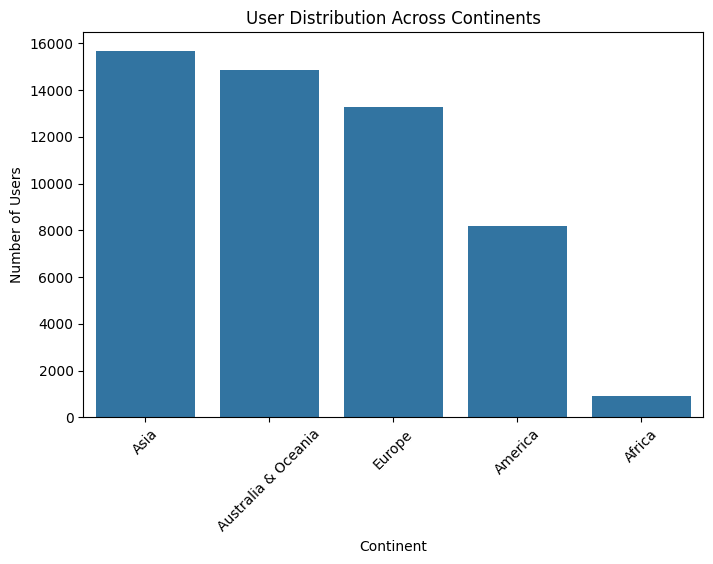

In [ ]:
# Users per Continents
plt.figure(figsize=(8,5))
continent_counts = df_master['Continent'].value_counts()

sns.barplot(x=continent_counts.index, y=continent_counts.values)
plt.title("User Distribution Across Continents")
plt.xlabel("Continent")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()


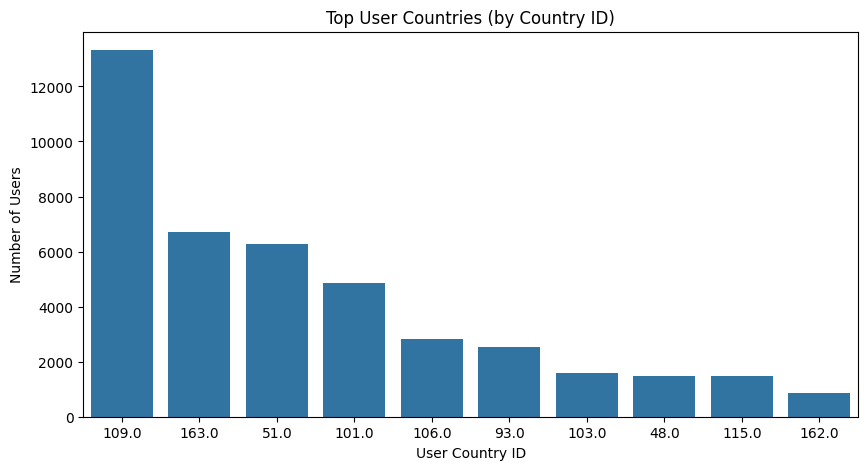

In [ ]:
# Users per user countryid
plt.figure(figsize=(10,5))

country_counts = df_master['UserCountryId'].value_counts().head(10)

sns.barplot(x=country_counts.index.astype(str), y=country_counts.values)

plt.title("Top User Countries (by Country ID)")
plt.xlabel("User Country ID")
plt.ylabel("Number of Users")

plt.show()

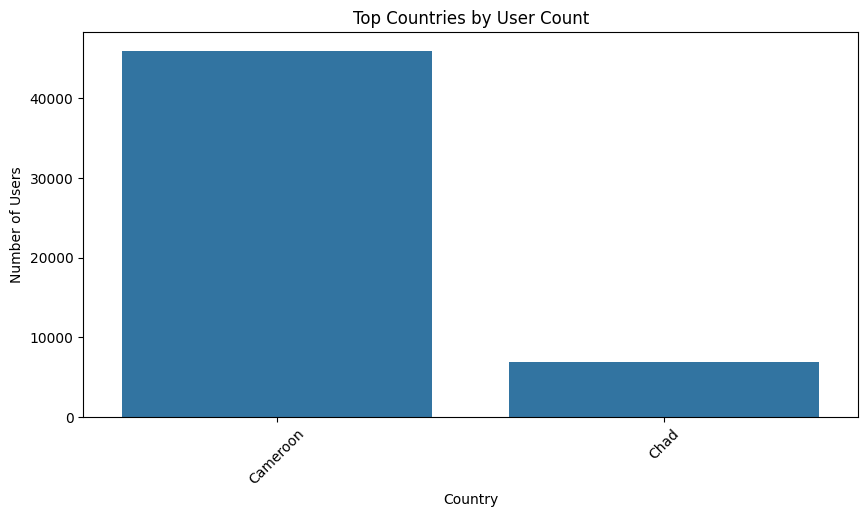

In [ ]:
plt.figure(figsize=(10,5))
country_counts = df_original['AttractionCountry'].value_counts().head(10)

sns.barplot(x=country_counts.index, y=country_counts.values)
plt.title("Top Countries by User Count")
plt.xlabel("Country")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

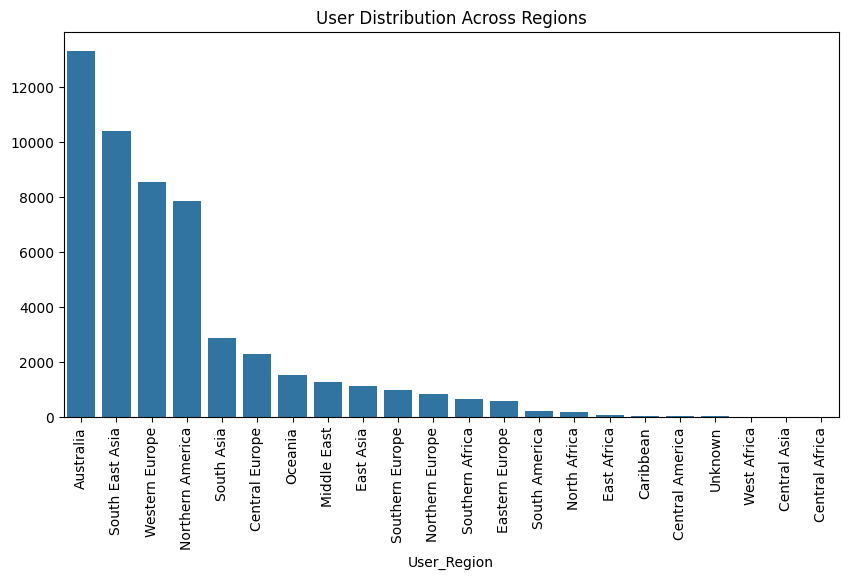

In [ ]:
# Users per Region
plt.figure(figsize=(10,5))
region_counts = df_master['User_Region'].value_counts()

sns.barplot(x=region_counts.index, y=region_counts.values)
plt.title("User Distribution Across Regions")
plt.xticks(rotation=90)
plt.show()

# 3.2 Attraction Types & Popularity Based on Ratings

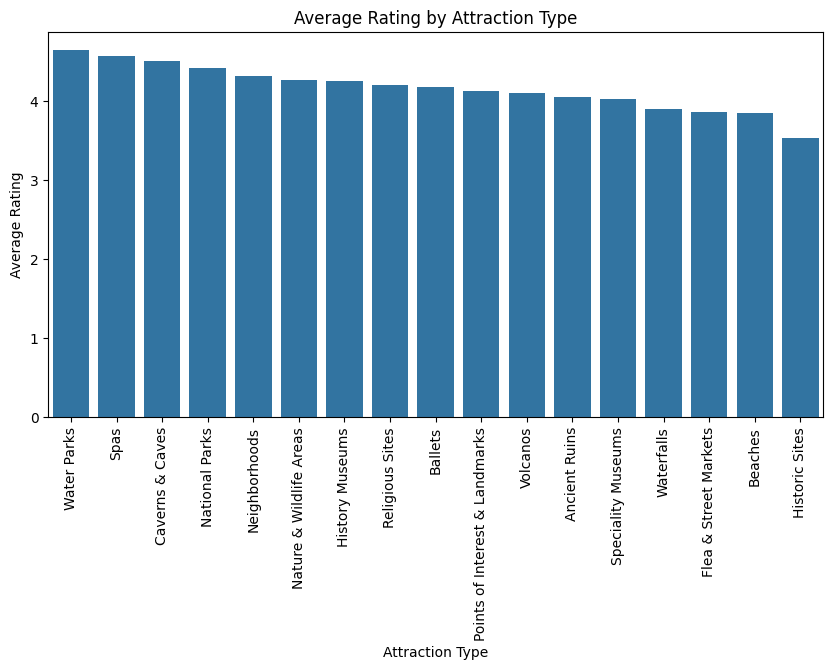

In [ ]:
# Average Rating by Attraction Type
attraction_rating = df_original.groupby('AttractionType')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=attraction_rating.index, y=attraction_rating.values)
plt.title("Average Rating by Attraction Type")
plt.xlabel("Attraction Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)
plt.show()

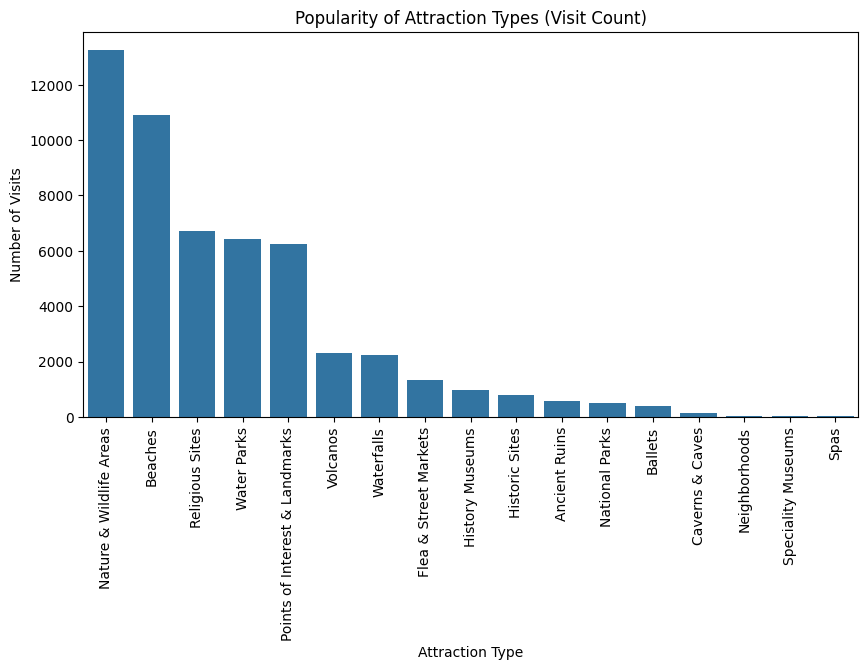

In [ ]:
# Most Popular Attraction Types (By Visit Count)
attraction_count = df_original['AttractionType'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=attraction_count.index, y=attraction_count.values)
plt.title("Popularity of Attraction Types (Visit Count)")
plt.xlabel("Attraction Type")
plt.ylabel("Number of Visits")
plt.xticks(rotation=90)
plt.show()


# 3.3 Correlation Between VisitMode & User Demographics

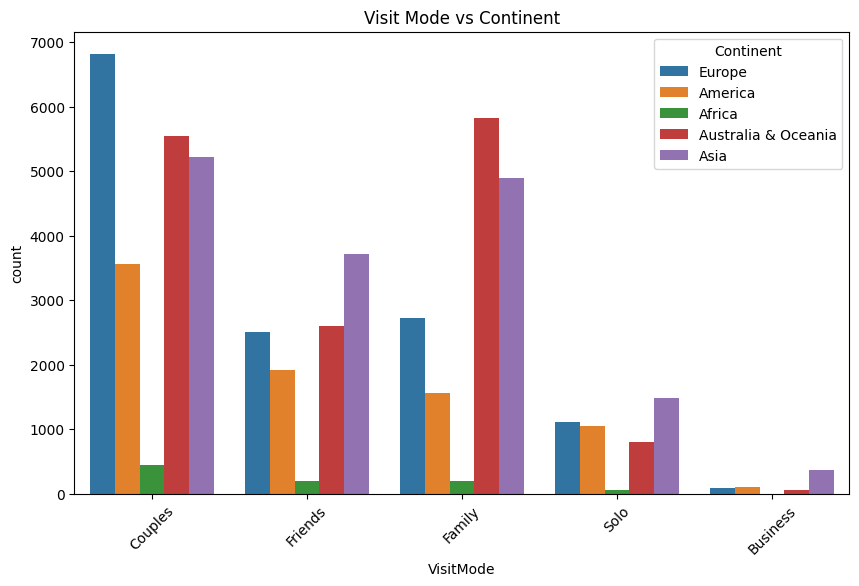

In [ ]:
# VisitMode vs Continent (Countplot)
plt.figure(figsize=(10,6))
sns.countplot(data=df_original, x='VisitMode', hue='Continent')
plt.title("Visit Mode vs Continent")
plt.xticks(rotation=45)
plt.show()

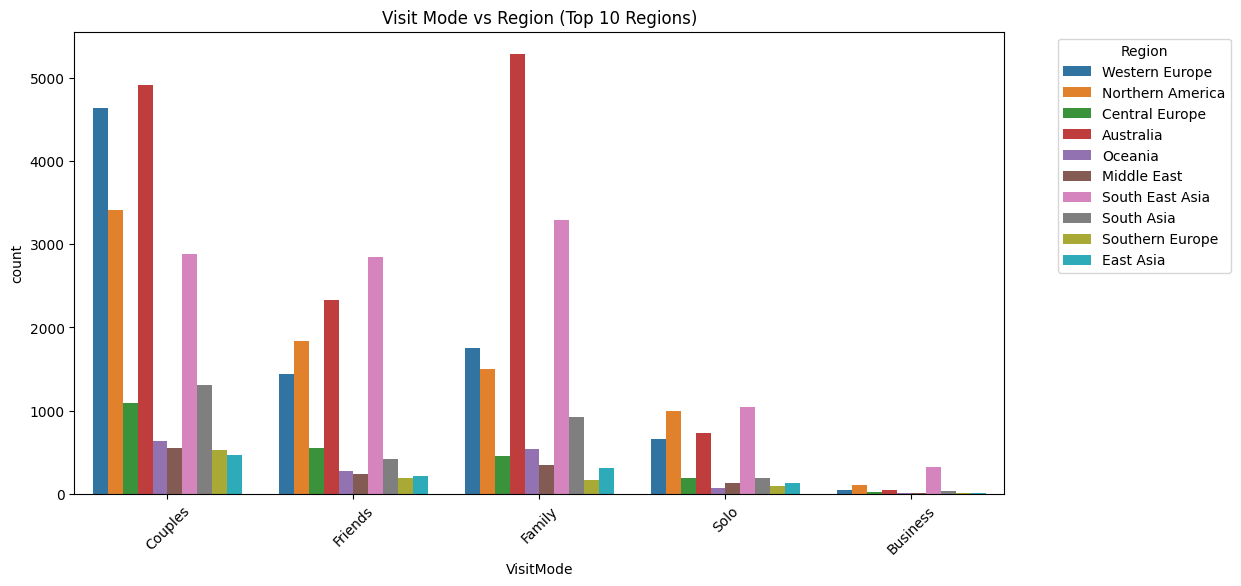

In [ ]:
# VisitMode vs Region
# Get top 10 regions
top_regions = df_original['User_Region'].value_counts().head(10).index

# Filter dataframe
df_filtered = df_original[df_original['User_Region'].isin(top_regions)]

# Plot
plt.figure(figsize=(12,6))
sns.countplot(data=df_filtered, x='VisitMode', hue='User_Region')

plt.title("Visit Mode vs Region (Top 10 Regions)")
plt.xticks(rotation=45)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

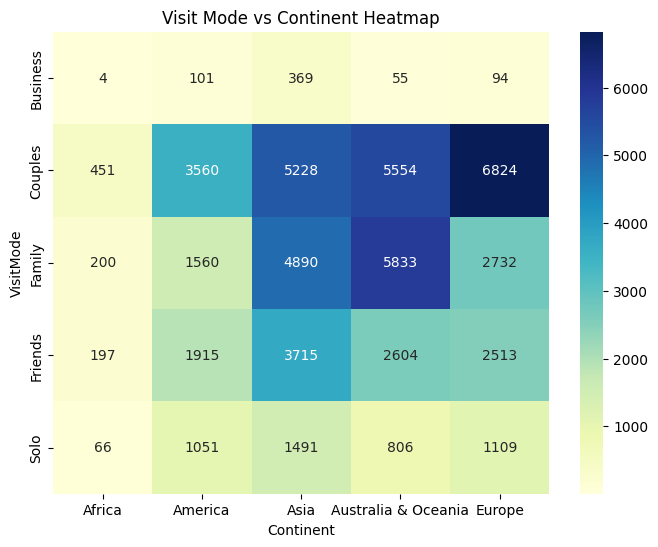

In [ ]:
# Crosstab Heatmap (Better Pattern Visualization)
visit_continent = pd.crosstab(df_original['VisitMode'], df_master['Continent'])

plt.figure(figsize=(8,6))
sns.heatmap(visit_continent, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Visit Mode vs Continent Heatmap")
plt.show()

# 3.4 Distribution of Ratings Across Attractions & Regions

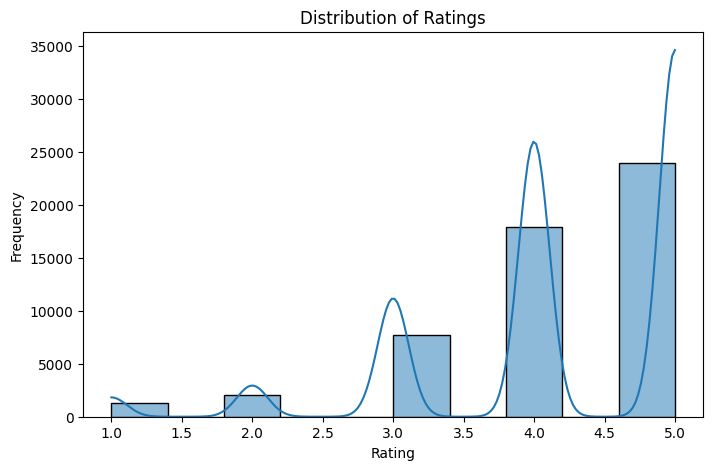

In [ ]:
# Overall Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df_original['Rating'], bins=10, kde=True)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

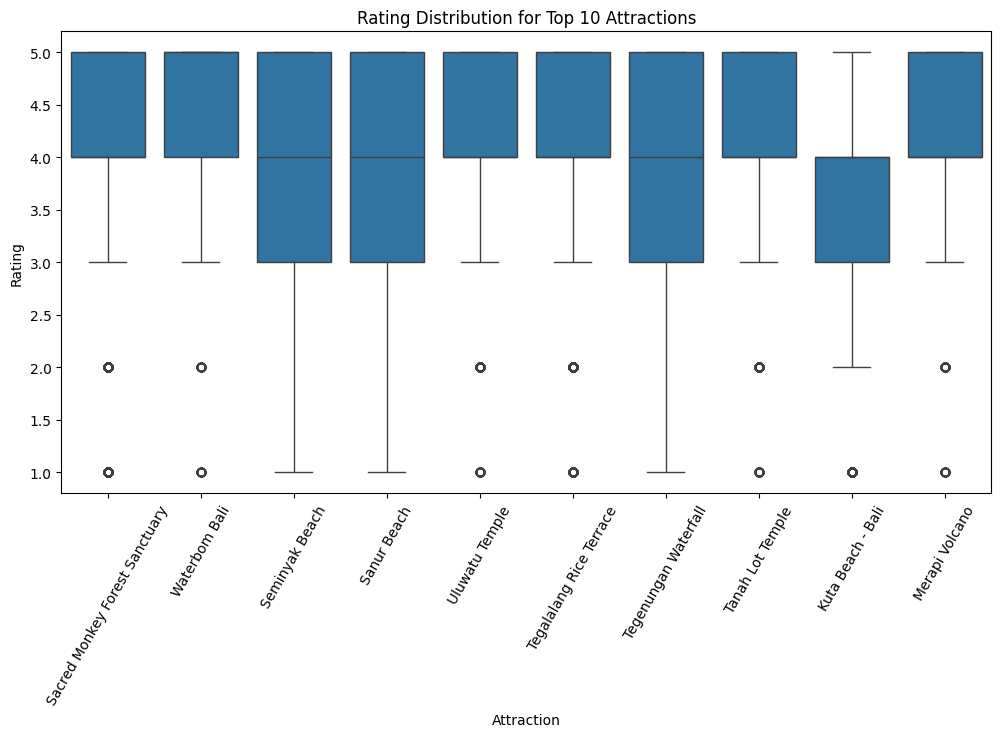

In [ ]:
# Ratings by Attraction (Top 10)
top_attractions = df_original['Attraction'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(data=df_original[df_master['Attraction'].isin(top_attractions)],
            x='Attraction', y='Rating')

plt.xticks(rotation=60)
plt.title("Rating Distribution for Top 10 Attractions")
plt.show()


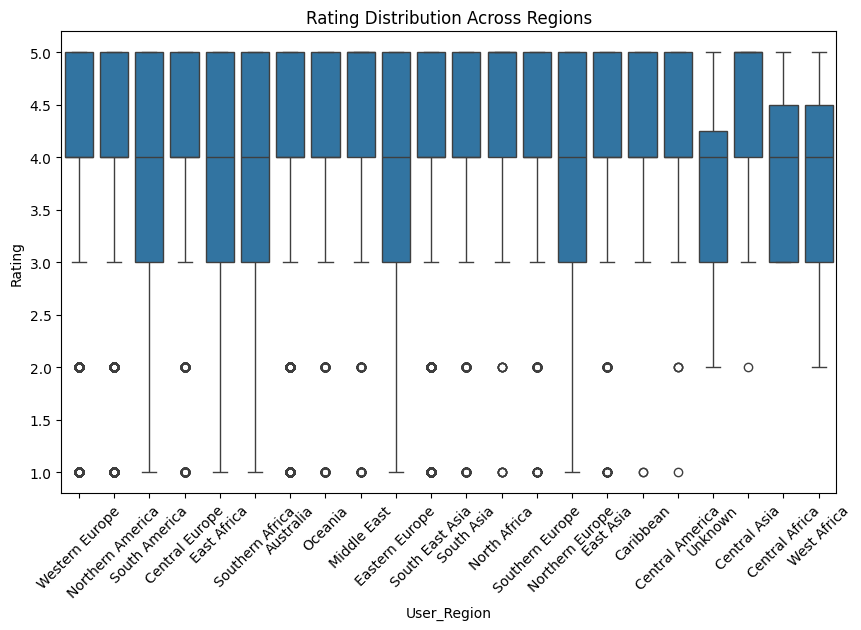

In [ ]:
# Ratings by Region
plt.figure(figsize=(10,6))
sns.boxplot(data=df_original, x='User_Region', y='Rating')
plt.xticks(rotation=45)
plt.title("Rating Distribution Across Regions")
plt.show()

## **4. Model Training**

### **4.1 Regression Task : Predicting Attraction Ratings**

### Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np

# ML models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Optional advanced models
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

### Step 2: Define Features and Target

In [ ]:
# Target variable
y = df_master['Rating']

# Drop obvious ID columns
drop_cols = ['Rating', 'TransactionId', 'UserId', 'AttractionId']
X = df_master.drop(columns=drop_cols, errors='ignore')

# Keep ONLY numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

### Step 3: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Step 4: Model 1 – Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MSE:", mse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MSE: 0.2003289115773722
R2 Score: 0.8013847824611935


### Step 5: Model 2 – Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Results")
print("MSE:", mse_rf)
print("R2 Score:", r2_rf)


Random Forest Results
MSE: 0.22244597756742548
R2 Score: 0.7794569147443164


### Step 6: Model 3 – XGBoost

In [ ]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBoost Results")
print("MSE:", mse_xgb)
print("R2 Score:", r2_xgb)


XGBoost Results
MSE: 0.2027639590610493
R2 Score: 0.7989705653525409


### Step 7: Compare All Models

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MSE": [mse_lr, mse_rf, mse_xgb],
    "R2 Score": [r2_lr, r2_rf, r2_xgb]
})

print("\nModel Comparison:")
print(results.sort_values(by="R2 Score", ascending=False))


Model Comparison:
               Model       MSE  R2 Score
0  Linear Regression  0.200329  0.801385
2            XGBoost  0.202764  0.798971
1      Random Forest  0.222446  0.779457


### Step 8: Feature Importance

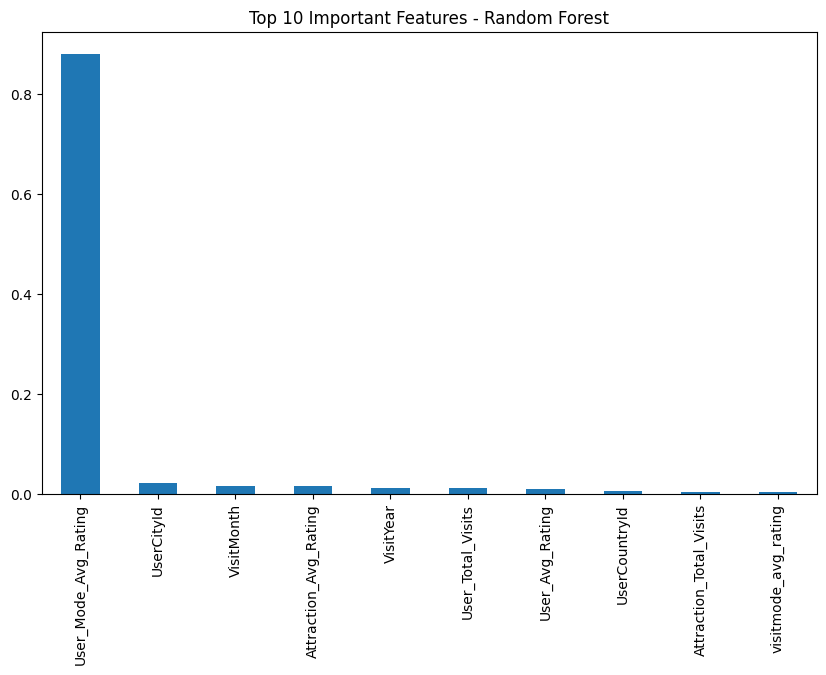

In [ ]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features - Random Forest")
plt.show()

## **4.2 Classification Task : User Visit Mode Prediction**

In [ ]:
df_master["VisitMode"].value_counts(normalize=True)

,proportion
VisitMode,
1,0.408469
2,0.287499
3,0.206795
4,0.085465
0,0.011772


In [ ]:
# ============================================
# USER VISIT MODE CLASSIFICATION
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --------------------------------------------
# 1️⃣ Copy Dataset
# --------------------------------------------
df = df_master.copy()

# --------------------------------------------
# 2️⃣ Define Target
# --------------------------------------------
y = df["VisitMode"]   # Already encoded

# --------------------------------------------
# 3️⃣ Select Features
# --------------------------------------------

features = [
    "VisitYear",
    "VisitMonth",
    "ContinentId",
    "UserRegionId",
    "UserCountryId",
    "UserCityId",
    "AttractionTypeId",
    "Attraction_Avg_Rating",
    "Attraction_Total_Visits",
    "User_Avg_Rating",
    "User_Total_Visits",
    "Rating"
]

X = df[features]

# --------------------------------------------
# 4️⃣ Train-Test Split
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------
# 5️⃣ Feature Scaling (for numeric stability)
# --------------------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------
# 6️⃣ Train Classifier (Random Forest)
# --------------------------------------------
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# --------------------------------------------
# 7️⃣ Predictions
# --------------------------------------------
y_pred = model.predict(X_test)

# --------------------------------------------
# 8️⃣ Evaluation
# --------------------------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.4117146905999055

Classification Report:

              precision    recall  f1-score   support

           0       0.08      0.57      0.14       124
           1       0.53      0.54      0.53      4324
           2       0.55      0.37      0.44      3043
           3       0.35      0.23      0.28      2189
           4       0.18      0.34      0.23       905

    accuracy                           0.41     10585
   macro avg       0.34      0.41      0.33     10585
weighted avg       0.46      0.41      0.42     10585


Confusion Matrix:

[[  71   20    7   16   10]
 [ 256 2342  551  467  708]
 [ 298  920 1137  326  362]
 [ 220  833  314  502  320]
 [  73  332   68  126  306]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# LightGBM
lgb = LGBMClassifier(n_estimators=500, random_state=42, class_weight="balanced")
lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_test)

# Compare
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("LightGBM Accuracy:", accuracy_score(y_test, lgb_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 42337, number of used features: 12
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Random Forest Accuracy: 0.512895606991025
LightGBM Accuracy: 0.46291922531884744


Random Forest is performing better

## **4.3 Recommendation Task : Personalized Attraction Suggestion**

In [ ]:
# ============================================
# COLLABORATIVE FILTERING (SPARSE VERSION)
# ============================================

import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# --------------------------------------------
# Step 1: Prepare Data (Memory Optimized)
# --------------------------------------------

df = df_master[['UserId', 'AttractionId', 'Rating']].copy()

# Reduce memory usage
df['UserId'] = df['UserId'].astype('int32')
df['AttractionId'] = df['AttractionId'].astype('int32')
df['Rating'] = df['Rating'].astype('float32')

# Convert to categorical codes
user_codes = df['UserId'].astype("category")
item_codes = df['AttractionId'].astype("category")

row = user_codes.cat.codes
col = item_codes.cat.codes
data = df['Rating']

# Create sparse user-item matrix
sparse_matrix = csr_matrix((data, (row, col)))

print("Sparse matrix shape:", sparse_matrix.shape)


# --------------------------------------------
# Step 2: Recommendation Function
# --------------------------------------------

def recommend_attractions(user_id, top_n=5, top_k_similar=5):

    # Get user index
    if user_id not in user_codes.cat.categories:
        return "User not found"

    user_index = user_codes.cat.categories.get_loc(user_id)

    # Compute similarity only for this user (memory safe)
    user_vector = sparse_matrix[user_index]
    similarities = cosine_similarity(user_vector, sparse_matrix).flatten()

    # Get top similar users (excluding self)
    similar_indices = similarities.argsort()[-(top_k_similar+1):-1][::-1]

    # Get ratings of similar users
    similar_ratings = sparse_matrix[similar_indices]

    # Mean rating for each attraction
    mean_ratings = similar_ratings.mean(axis=0)
    mean_ratings = np.array(mean_ratings).flatten()

    # Remove already visited attractions
    user_ratings = sparse_matrix[user_index].toarray().flatten()
    mean_ratings[user_ratings > 0] = 0

    # Get top recommended attractions
    top_items = mean_ratings.argsort()[-top_n:][::-1]

    recommended_attractions = item_codes.cat.categories[top_items]

    return list(recommended_attractions)

Sparse matrix shape: (33526, 30)


### Model Evaluation

In [ ]:
# ============================================
# RMSE EVALUATION
# ============================================

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

# Use smaller sample for safety
df_eval = df.sample(50000, random_state=42)

# Train-test split
train_df, test_df = train_test_split(df_eval, test_size=0.2, random_state=42)

# Rebuild sparse matrix using TRAIN data only
user_codes = train_df['UserId'].astype("category")
item_codes = train_df['AttractionId'].astype("category")

row = user_codes.cat.codes
col = item_codes.cat.codes
data = train_df['Rating']

from scipy.sparse import csr_matrix
sparse_train = csr_matrix((data, (row, col)))

from sklearn.metrics.pairwise import cosine_similarity

def predict_rating(user_id, item_id):

    if user_id not in user_codes.cat.categories:
        return train_df['Rating'].mean()

    user_index = user_codes.cat.categories.get_loc(user_id)

    similarities = cosine_similarity(
        sparse_train[user_index],
        sparse_train
    ).flatten()

    similar_users = similarities.argsort()[-6:-1]

    # Get item index
    if item_id not in item_codes.cat.categories:
        return train_df['Rating'].mean()

    item_index = item_codes.cat.categories.get_loc(item_id)

    ratings = sparse_train[similar_users, item_index].toarray().flatten()

    if ratings.sum() == 0:
        return train_df['Rating'].mean()

    return ratings.mean()


# Predict on test set (small sample)
test_sample = test_df.sample(1000, random_state=42)

predictions = []
actuals = []

for _, row in test_sample.iterrows():
    pred = predict_rating(row['UserId'], row['AttractionId'])
    predictions.append(pred)
    actuals.append(row['Rating'])

rmse = np.sqrt(mean_squared_error(actuals, predictions))
print("RMSE:", rmse)

RMSE: 1.0191523678831926


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Split dataset
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

def evaluate_map_correct(k=5, sample_users=100):

    users = train_df['UserId'].unique()[:sample_users]
    ap_scores = []

    for user in users:

        # Actual items in TEST set
        actual_items = test_df[test_df['UserId'] == user]['AttractionId'].tolist()

        if len(actual_items) == 0:
            continue

        predicted_items = recommend_attractions(user_id=user, top_n=k)

        if isinstance(predicted_items, list):
            ap = average_precision(actual_items, predicted_items, k)
            ap_scores.append(ap)

    if len(ap_scores) == 0:
        return 0

    return np.mean(ap_scores)
# ============================================
# AVERAGE PRECISION FUNCTION
# ============================================

def average_precision(actual, predicted, k=5):

    score = 0.0
    hits = 0.0

    for i in range(min(len(predicted), k)):
        if predicted[i] in actual:
            hits += 1
            score += hits / (i + 1.0)

    if len(actual) == 0:
        return 0.0

    return score / min(len(actual), k)

map_score = evaluate_map_correct(k=5)
print("Correct MAP@5:", map_score)

Correct MAP@5: 0.075


In [ ]:
import joblib

In [ ]:
joblib.dump(model, "visit_mode_model.pkl",compress=True)
print("Visit mode model saved successfully!")

Visit mode model saved successfully!


In [ ]:
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully!")

Scaler saved successfully!


In [ ]:
joblib.dump(le, "label_encoder.pkl")
print("Label encoder saved successfully!")

Label encoder saved successfully!


In [ ]:
df_master.to_csv("df_master.csv", index=False)
print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
from google.colab import files

files.download("visit_mode_model.pkl")
files.download("scaler.pkl")
files.download("label_encoder.pkl")
files.download("df_master.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Conclusion**

The "Tourism Experience Analytics" platform successfully demonstrates how machine learning can transform raw travel data into actionable insights. By moving from generic travel suggestions to personalized, behavior-based recommendations, the project provides a scalable solution to improve customer retention and optimize resource allocation for tourism businesses. The final Streamlit application serves as a bridge between complex data science models and end-user utility.